In [20]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))


from pathlib import Path

#OUT = Path("figures"); OUT.mkdir(exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

DATA_ROOT = 'DATAPATH'   
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
def analyze_data_common(datapath, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                        transients=False, dim_red=False, max_dim=4, standardize='stand'):
    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context

    analysis_func, context_func = get_analysis_function(analysis_type)

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    hists = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference=reference, maps=maps, 
                                                 reference_type='no_reference', hist='hist', transients=transients, 
                                                 dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g = apply_analysis(analysis_func, hists)
    hists_2 = analysis.sort_maps_from_reference_AK(datapath, 'Context2', reference=reference, maps=maps, 
                                                   reference_type='no_reference', hist='hist', transients=transients,
                                                     dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g_2 = apply_analysis(analysis_func, hists_2)

    global_seeds = [1,2,3,4,5]
    simu_g_list = []
    for seed in global_seeds:
        simu_drift = analysis.simulate_drift(datapath, session='0', Context='Context1', days=len(maps)+1, drift_type='circular', 
                                             dim_red=dim_red, standardize=standardize, odd_even=True, global_seed=seed, 
                                             active_days=[reference]+maps, remove_day_inactive=True,
                                             max_remap_prob=0.3, amplitude_drift_prob=0.3, amplitude_change_scale=0.5)
        simu_g = apply_analysis(analysis_func, simu_drift['maps'])
        simu_g_list.append(simu_g)
    simu_g_array = np.array(simu_g_list)
    simu_g = np.mean(simu_g_array, axis=0)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=maps, 
                                                                                  transients=transients, dim_red=dim_red, standardize=standardize, 
                                                                                  remove_day_inactive=False)
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)
    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context2', maps=maps, transients=transients, dim_red=dim_red, standardize=standardize, remove_day_inactive=False)
    g_odd_even2 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':              
        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context1', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                            standardize=standardize, remove_day_inactive=False)
        shuff1_con2, shuff2_con2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context2', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                                      standardize=standardize, remove_day_inactive=False)
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])
        g_shuff2 = apply_analysis(context_func, [shuff1_con2], [shuff2_con2])
        
        g = (g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
        g_2 = (g_2 - np.mean(g_odd_even2)) / (np.mean(g_shuff2) - np.mean(g_odd_even2))
        simu_g = (simu_g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
    else:
        g = g- np.mean(g_odd_even1)
        g_2 = g_2- np.mean(g_odd_even2)
        simu_g = simu_g-np.mean(g_odd_even1)

    if compute_day11_12:
        hists_day11 = [h for h, m in zip(hists[1:], maps) if m == '17']
        hists_day12 = [h for h, m in zip(hists[1:], maps) if m == '19']
        hists_2_day12 = [h for h, m in zip(hists_2[1:], maps) if m == '19']

        g_day11_12_context1 = apply_analysis(context_func, hists_day11, hists_day12)
        g_day12_contexts = apply_analysis(context_func, hists_day12, hists_2_day12)

        g_odd_even_comparison = np.mean([g_odd_even1[maps.index('17')],
                                         g_odd_even1[maps.index('19')],
                                         g_odd_even2[maps.index('19')]])

        if analysis_type == 'population_geometry':
            shuff_fam_17, _ = analysis.shuffle_two_sessions_hist(datapath, '17', '19', 'Context1', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                                 standardize=standardize, remove_day_inactive=False)
            g_shuff_11_12 = apply_analysis(context_func, [shuff_fam_17], [shuff2_con2])

            g_day12_contexts_norm = (g_day12_contexts - g_odd_even_comparison) / (np.mean(g_shuff_11_12) - g_odd_even_comparison)
            g_day11_12_context1_norm = (g_day11_12_context1 - g_odd_even_comparison) / (np.mean(g_shuff_11_12) - g_odd_even_comparison)
        else:
            g_day12_contexts_norm = g_day12_contexts - g_odd_even_comparison
            g_day11_12_context1_norm = g_day11_12_context1 - g_odd_even_comparison

        return g, g_2, simu_g, g_day12_contexts_norm, g_day11_12_context1_norm
    else:
        return g, g_2, simu_g


def collect_data(datapaths, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                 transients=False, dim_red=False, max_dim=4, standardize='stand'):
    all_data = []
    for datapath in datapaths:
        data = analyze_data_common(datapath, reference, maps, analysis_type, method=method, compute_day11_12=compute_day11_12, 
                                   transients=transients, dim_red=dim_red, max_dim=max_dim, standardize=standardize)
        all_data.append(data)
    return all_data

if __name__ == "__main__":
    transients = False
    dim_red = False
    max_dim = 4

    reference = '0'
    maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
    forward_data_pop_geometry_subspace = collect_data(datapaths, reference, maps, 'population_geometry', method='subspace',
                                                       compute_day11_12=True, transients=transients, dim_red=dim_red, standardize='stand')
    forward_data_pop_geometry_angles = collect_data(datapaths, reference, maps, 'population_geometry', method='angles', 
                                                    compute_day11_12=True, transients=transients, dim_red=dim_red, standardize='stand')
    forward_data_topology = collect_data(datapaths, reference, maps, 'topology', compute_day11_12=True, 
                                         transients=transients, dim_red=dim_red, max_dim=max_dim, standardize='stand')

    reference_reverse = '19'
    maps_reverse =  ['17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]
    reverse_data_pop_geometry_subspace = collect_data(datapaths, reference_reverse, maps_reverse, 'population_geometry', 
                                                      method='subspace', compute_day11_12=False, transients=transients, dim_red=dim_red,standardize='stand' )
    reverse_data_pop_geometry_angles = collect_data(datapaths, reference_reverse, maps_reverse, 'population_geometry', 
                                                    method='angles', compute_day11_12=False, transients=transients, dim_red=dim_red,  standardize='stand')
    reverse_data_topology = collect_data(datapaths, reference_reverse, maps_reverse, 'topology', 
                                         compute_day11_12=False, transients=transients, dim_red=dim_red, max_dim=max_dim, standardize='stand')

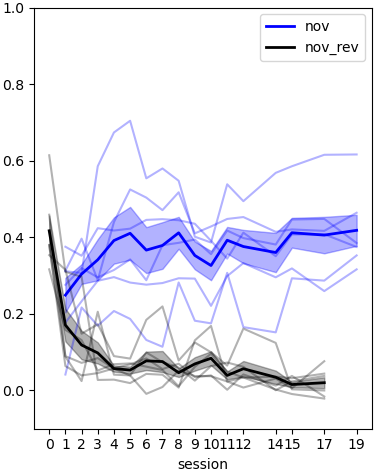

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.0415,0.2166,0.1690,0.2074,0.1868,0.1318,0.1140,0.2819,0.1820,0.1752,0.3071,0.1654,0.1516,0.2928,0.2867,0.3525
51004,0.3113,0.3066,0.5855,0.6736,0.7042,0.5538,0.5797,0.5475,0.4014,0.3862,0.5383,0.4942,0.5682,0.5854,0.6154,0.6162
51007,0.3752,0.3517,0.4237,0.4176,0.4224,0.4453,0.4472,0.4445,0.4353,0.3907,0.3441,0.4120,0.3506,0.4073,0.4078,0.3747
63,0.3127,0.3963,0.2880,0.4397,0.5248,0.5035,0.4708,0.5174,0.4102,0.4282,0.4478,0.4527,0.4142,0.4204,0.4167,0.4640
64,0.1772,0.2328,0.2863,0.2959,0.2817,0.2762,0.2804,0.2929,0.2920,0.2209,0.2986,0.3326,0.2954,0.3186,0.2594,0.3162
65,0.2756,0.3196,0.2952,0.3145,0.3422,0.2878,0.3792,0.3854,0.3940,0.3559,0.4175,0.3978,0.3810,0.4463,0.4479,0.3849


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,0.3534,0.3151,0.1481,0.1727,0.0897,0.0831,0.1843,0.2194,0.0782,0.1252,0.0996,0.0649,0.1615,0.1241,0.0029,-0.0002
51004,0.6141,0.3097,0.2968,0.0274,0.0282,0.0191,0.0432,0.0410,0.0075,0.1307,0.1684,0.0230,0.0338,0.0023,-0.0094,-0.0213
51007,0.3789,0.0636,0.0391,0.0453,0.0576,0.0682,0.0835,0.0559,0.0697,0.0347,0.0392,0.0018,0.0417,0.0126,0.0379,-0.0158
63,0.4589,0.0880,0.0245,0.2055,0.0412,0.0393,-0.0089,0.0090,0.0520,0.0375,0.0372,0.0234,0.0075,0.0311,0.0056,0.0763
64,0.3162,0.1583,0.1314,0.0520,0.0685,0.0706,0.0621,0.0533,0.0108,0.0617,0.0958,0.0494,0.0335,0.0360,0.0319,0.0439
65,0.3801,0.0894,0.0720,0.0845,0.0571,0.0389,0.0992,0.0738,0.0596,0.0256,0.0635,0.0729,0.0617,0.0005,0.0235,0.0379


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.180200,15,75,0.012013,4.292219,1.103644e-05,0.017707,0.098559,0.22333
1,condition,3.734187,1,5,3.734187,28.055926,3.200491e-03,0.003200,0.693786,1.00000
2,time * condition,0.831365,15,75,0.055424,13.237445,1.880298e-15,0.000853,0.335294,0.15129


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1 | d0,nov,nov_rev,t-test,-3.4477,0.0183,0.2925,,-1.4075,Cohen's d,0.2489,0.4169,-0.1680,0.1194,6,True,0.4301
1,d2 | d1,nov,nov_rev,t-test,1.9518,0.1084,1.0000,,0.7968,Cohen's d,0.3039,0.1707,0.1332,0.1672,6,True,0.4502
2,d3 | d2,nov,nov_rev,t-test,4.3785,0.0072,0.1146,,1.7875,Cohen's d,0.3413,0.1186,0.2226,0.1246,6,True,0.9233
3,d4 | d3,nov,nov_rev,t-test,3.5285,0.0168,0.2683,,1.4405,Cohen's d,0.3915,0.0979,0.2936,0.2038,6,True,0.4185
4,d5 | d4,nov,nov_rev,t-test,4.2110,0.0084,0.1344,,1.7191,Cohen's d,0.4104,0.0570,0.3533,0.2055,6,True,0.9568
5,d6 | d5,nov,nov_rev,t-test,4.2670,0.0080,0.1274,,1.7420,Cohen's d,0.3664,0.0532,0.3132,0.1798,6,True,0.9067
6,d7 | d6,nov,nov_rev,t-test,3.3940,0.0194,0.3100,,1.3856,Cohen's d,0.3786,0.0772,0.3013,0.2175,6,True,0.6413
7,d8 | d7,nov,nov_rev,t-test,4.8154,0.0048,0.0771,,1.9659,Cohen's d,0.4116,0.0754,0.3362,0.1710,6,True,0.5656
8,d9 | d8,nov,nov_rev,t-test,7.0683,0.0009,0.0140,*,2.8856,Cohen's d,0.3525,0.0463,0.3062,0.1061,6,True,0.0594
9,d10 | d9,nov,nov_rev,t-test,4.8143,0.0048,0.0772,,1.9654,Cohen's d,0.3262,0.0692,0.2570,0.1307,6,True,0.5289


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,0.3534,0.3151,0.1481,0.1727,0.0897,0.0831,0.1843,0.2194,0.0782,0.1252,0.0996,0.0649,0.1615,0.1241,0.0029,-0.0002
51004,0.6141,0.3097,0.2968,0.0274,0.0282,0.0191,0.0432,0.0410,0.0075,0.1307,0.1684,0.0230,0.0338,0.0023,-0.0094,-0.0213
51007,0.3789,0.0636,0.0391,0.0453,0.0576,0.0682,0.0835,0.0559,0.0697,0.0347,0.0392,0.0018,0.0417,0.0126,0.0379,-0.0158
63,0.4589,0.0880,0.0245,0.2055,0.0412,0.0393,-0.0089,0.0090,0.0520,0.0375,0.0372,0.0234,0.0075,0.0311,0.0056,0.0763
64,0.3162,0.1583,0.1314,0.0520,0.0685,0.0706,0.0621,0.0533,0.0108,0.0617,0.0958,0.0494,0.0335,0.0360,0.0319,0.0439
65,0.3801,0.0894,0.0720,0.0845,0.0571,0.0389,0.0992,0.0738,0.0596,0.0256,0.0635,0.0729,0.0617,0.0005,0.0235,0.0379


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.820152,15,0.054677,16.075483,1.131602e-17,0.719556,0.175289
1,Error,0.255094,75,0.003401,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.0415,0.2166,0.1690,0.2074,0.1868,0.1318,0.1140,0.2819,0.1820,0.1752,0.3071,0.1654,0.1516,0.2928,0.2867,0.3525
51004,0.3113,0.3066,0.5855,0.6736,0.7042,0.5538,0.5797,0.5475,0.4014,0.3862,0.5383,0.4942,0.5682,0.5854,0.6154,0.6162
51007,0.3752,0.3517,0.4237,0.4176,0.4224,0.4453,0.4472,0.4445,0.4353,0.3907,0.3441,0.4120,0.3506,0.4073,0.4078,0.3747
63,0.3127,0.3963,0.2880,0.4397,0.5248,0.5035,0.4708,0.5174,0.4102,0.4282,0.4478,0.4527,0.4142,0.4204,0.4167,0.4640
64,0.1772,0.2328,0.2863,0.2959,0.2817,0.2762,0.2804,0.2929,0.2920,0.2209,0.2986,0.3326,0.2954,0.3186,0.2594,0.3162
65,0.2756,0.3196,0.2952,0.3145,0.3422,0.2878,0.3792,0.3854,0.3940,0.3559,0.4175,0.3978,0.3810,0.4463,0.4479,0.3849


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.191413,15,0.012761,3.559971,0.000127,0.125937,0.192629
1,Error,0.268841,75,0.003585,NaN,NaN,NaN,NaN


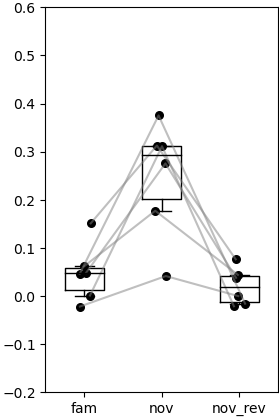

condition,fam (d0->d1),nov (d0->d1),nov_rev (d19->d17)
animal,,,
170,-0.0218,0.0415,-0.0002
51004,0.0010,0.3113,-0.0213
51007,0.0461,0.3752,-0.0158
63,0.1510,0.3127,0.0763
64,0.0616,0.1772,0.0439
65,0.0479,0.2756,0.0379


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.187229,2,0.093615,19.437649,0.000359,0.656149,0.542493
1,Error,0.048161,10,0.004816,NaN,NaN,NaN,NaN


condition,fam (d0->d1),nov (d0->d1),nov_rev (d19->d17)
animal,,,
170,-0.0218,0.0415,-0.0002
51004,0.0010,0.3113,-0.0213
51007,0.0461,0.3752,-0.0158
63,0.1510,0.3127,0.0763
64,0.0616,0.1772,0.0439
65,0.0479,0.2756,0.0379


,Timepoint 1,Timepoint 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Diff,SD Diff,Normal Dist.,Normality p-value
0,fam (d0->d1),nov (d0->d1),t-test,-4.6237,0.0057,0.0171,*,-1.8876,Cohen's d,-0.2013,0.1066,True,0.6718
1,fam (d0->d1),nov_rev (d19->d17),t-test,1.9031,0.1154,0.3462,,0.7769,Cohen's d,0.0275,0.0354,True,0.7065
2,nov (d0->d1),nov_rev (d19->d17),t-test,4.3929,0.0071,0.0212,*,1.7934,Cohen's d,0.2288,0.1276,True,0.8806


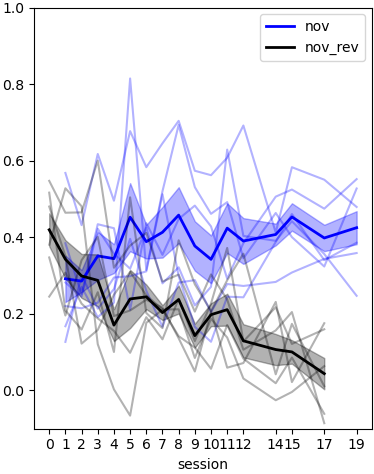

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.3844,0.2508,0.4341,0.4236,0.2105,0.4368,0.3542,0.4477,0.4827,0.4284,0.2916,0.3845,0.5061,0.5245,0.4746,0.5518
51004,0.2203,0.2146,0.2292,0.2949,0.2985,0.3109,0.5122,0.2987,0.1660,0.1270,0.2448,0.2432,0.3878,0.4606,0.3403,0.3857
51007,0.5679,0.4316,0.6175,0.4954,0.6772,0.5830,0.6453,0.7040,0.5736,0.5621,0.6076,0.6919,0.4123,0.5829,0.5503,0.4791
63,0.1676,0.2705,0.1912,0.2295,0.8147,0.3145,0.5202,0.6935,0.5308,0.4612,0.4918,0.3451,0.4634,0.4004,0.3236,0.5273
64,0.2819,0.2449,0.4222,0.3570,0.3180,0.4255,0.2796,0.3215,0.2220,0.2707,0.6289,0.4036,0.3907,0.4420,0.3562,0.2471
65,0.1268,0.3008,0.2137,0.2647,0.3957,0.2603,0.1664,0.2816,0.2880,0.2045,0.2779,0.2728,0.2834,0.3079,0.3435,0.3588


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,0.5473,0.4640,0.4650,0.6003,0.3204,0.3783,0.4114,0.2842,0.3026,0.2058,0.3030,0.2373,0.1064,0.1567,0.2047,-0.0856
51004,0.3806,0.5279,0.4809,0.1208,0.0028,-0.0658,0.1765,0.2113,0.2118,0.0848,0.1870,0.1382,0.0311,-0.0256,-0.0040,0.0634
51007,0.4802,0.3508,0.1222,0.1580,0.2498,0.3096,0.2484,0.2114,0.1418,0.1119,0.0566,0.1708,0.0831,0.0188,0.0858,-0.0611
63,0.5165,0.2089,0.1589,0.2565,0.1004,0.5042,0.2022,0.1628,0.3921,0.2772,0.2072,0.0594,0.0716,0.2312,0.0219,0.1755
64,0.2450,0.3076,0.2266,0.1882,0.1554,0.0983,0.1912,0.1335,0.2395,0.1290,0.2269,0.3721,0.1280,0.2172,0.1215,0.1597
65,0.3472,0.1956,0.3400,0.4009,0.1942,0.2089,0.2368,0.2161,0.1362,0.0496,0.2062,0.2877,0.3570,0.0421,0.1738,0.0109


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.215379,15,75,0.014359,1.276297,0.238533,0.315486,0.067499,0.234243
1,condition,1.497350,1,5,1.497350,12.898201,0.015685,0.015685,0.334767,1.000000
2,time * condition,0.884679,15,75,0.058979,4.628118,0.000004,0.009434,0.229183,0.254958


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1 | d0,nov,nov_rev,t-test,-1.9200,0.1129,1.0000,,-0.7838,Cohen's d,0.2915,0.4195,-0.1280,0.1633,6,True,0.6250
1,d2 | d1,nov,nov_rev,t-test,-0.8064,0.4566,1.0000,,-0.3292,Cohen's d,0.2855,0.3425,-0.0569,0.1729,6,True,0.2663
2,d3 | d2,nov,nov_rev,t-test,0.4858,0.6476,1.0000,,0.1983,Cohen's d,0.3513,0.2990,0.0524,0.2639,6,True,0.7645
3,d4 | d3,nov,nov_rev,t-test,0.6887,0.5217,1.0000,,0.2811,Cohen's d,0.3442,0.2874,0.0568,0.2019,6,True,0.5652
4,d5 | d4,nov,nov_rev,t-test,2.4965,0.0547,0.8755,,1.0192,Cohen's d,0.4524,0.1705,0.2819,0.2766,6,True,0.9563
5,d6 | d5,nov,nov_rev,t-test,1.7026,0.1494,1.0000,,0.6951,Cohen's d,0.3885,0.2389,0.1496,0.2152,6,True,0.4786
6,d7 | d6,nov,nov_rev,t-test,1.9824,0.1043,1.0000,,0.8093,Cohen's d,0.4130,0.2444,0.1686,0.2083,6,True,0.1775
7,d8 | d7,nov,nov_rev,t-test,3.0476,0.0285,0.4560,,1.2442,Cohen's d,0.4578,0.2032,0.2546,0.2046,6,True,0.0933
8,d9 | d8,nov,nov_rev,t-test,2.0033,0.1015,1.0000,,0.8178,Cohen's d,0.3772,0.2373,0.1399,0.1710,6,True,0.4018
9,d10 | d9,nov,nov_rev,t-test,3.5661,0.0161,0.2578,,1.4558,Cohen's d,0.3423,0.1431,0.1993,0.1369,6,True,0.2823


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,0.5473,0.4640,0.4650,0.6003,0.3204,0.3783,0.4114,0.2842,0.3026,0.2058,0.3030,0.2373,0.1064,0.1567,0.2047,-0.0856
51004,0.3806,0.5279,0.4809,0.1208,0.0028,-0.0658,0.1765,0.2113,0.2118,0.0848,0.1870,0.1382,0.0311,-0.0256,-0.0040,0.0634
51007,0.4802,0.3508,0.1222,0.1580,0.2498,0.3096,0.2484,0.2114,0.1418,0.1119,0.0566,0.1708,0.0831,0.0188,0.0858,-0.0611
63,0.5165,0.2089,0.1589,0.2565,0.1004,0.5042,0.2022,0.1628,0.3921,0.2772,0.2072,0.0594,0.0716,0.2312,0.0219,0.1755
64,0.2450,0.3076,0.2266,0.1882,0.1554,0.0983,0.1912,0.1335,0.2395,0.1290,0.2269,0.3721,0.1280,0.2172,0.1215,0.1597
65,0.3472,0.1956,0.3400,0.4009,0.1942,0.2089,0.2368,0.2161,0.1362,0.0496,0.2062,0.2877,0.3570,0.0421,0.1738,0.0109


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.846348,15,0.056423,4.50341,0.000006,0.421501,0.249999
1,Error,0.939675,75,0.012529,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.3844,0.2508,0.4341,0.4236,0.2105,0.4368,0.3542,0.4477,0.4827,0.4284,0.2916,0.3845,0.5061,0.5245,0.4746,0.5518
51004,0.2203,0.2146,0.2292,0.2949,0.2985,0.3109,0.5122,0.2987,0.1660,0.1270,0.2448,0.2432,0.3878,0.4606,0.3403,0.3857
51007,0.5679,0.4316,0.6175,0.4954,0.6772,0.5830,0.6453,0.7040,0.5736,0.5621,0.6076,0.6919,0.4123,0.5829,0.5503,0.4791
63,0.1676,0.2705,0.1912,0.2295,0.8147,0.3145,0.5202,0.6935,0.5308,0.4612,0.4918,0.3451,0.4634,0.4004,0.3236,0.5273
64,0.2819,0.2449,0.4222,0.3570,0.3180,0.4255,0.2796,0.3215,0.2220,0.2707,0.6289,0.4036,0.3907,0.4420,0.3562,0.2471
65,0.1268,0.3008,0.2137,0.2647,0.3957,0.2603,0.1664,0.2816,0.2880,0.2045,0.2779,0.2728,0.2834,0.3079,0.3435,0.3588


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.253710,15,0.016914,1.475306,0.136605,0.122709,0.208599
1,Error,0.859855,75,0.011465,NaN,NaN,NaN,NaN


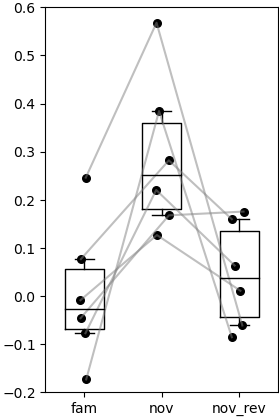

condition,fam (d0->d1),nov (d0->d1),nov_rev (d19->d17)
animal,,,
170,-0.1733,0.3844,-0.0856
51004,-0.0773,0.2203,0.0634
51007,0.2461,0.5679,-0.0611
63,-0.0460,0.1676,0.1755
64,0.0767,0.2819,0.1597
65,-0.0087,0.1268,0.0109


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.292577,2,0.146288,7.576561,0.009932,0.496058,0.742999
1,Error,0.193080,10,0.019308,NaN,NaN,NaN,NaN


condition,fam (d0->d1),nov (d0->d1),nov_rev (d19->d17)
animal,,,
170,-0.1733,0.3844,-0.0856
51004,-0.0773,0.2203,0.0634
51007,0.2461,0.5679,-0.0611
63,-0.0460,0.1676,0.1755
64,0.0767,0.2819,0.1597
65,-0.0087,0.1268,0.0109


,Timepoint 1,Timepoint 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Diff,SD Diff,Normal Dist.,Normality p-value
0,fam (d0->d1),nov (d0->d1),t-test,-4.7741,0.0050,0.0150,*,-1.9490,Cohen's d,-0.2886,0.1481,True,0.2976
1,fam (d0->d1),nov_rev (d19->d17),t-test,-0.5461,0.6085,1.0000,,-0.2230,Cohen's d,-0.0409,0.1834,True,0.1147
2,nov (d0->d1),nov_rev (d19->d17),t-test,2.4707,0.0565,0.1694,,1.0087,Cohen's d,0.2477,0.2456,True,0.2238


C:\Users\oles\AppData\Local\Temp\ipykernel_31432\4185163865.py:102: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


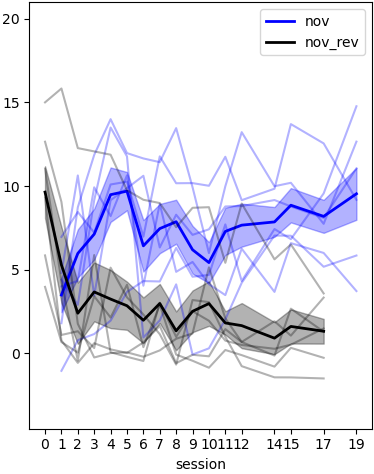

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-1.0406,0.7926,1.1588,1.9609,3.6746,4.3242,4.2992,6.3022,4.5826,4.6915,7.7094,4.3254,7.4333,6.8284,9.5595,14.7699
51004,4.3998,2.9054,9.1521,13.4987,11.7733,0.9551,1.9725,4.1267,-0.0691,0.3044,2.0315,4.2195,7.0420,7.0328,5.1793,5.8506
51007,4.0050,4.3347,9.9254,8.2046,10.6390,4.0457,8.9430,4.8756,5.4649,4.1404,3.4842,6.2574,3.6761,6.5899,6.0045,3.7261
63,4.8031,10.6335,3.4499,9.1544,9.8720,10.6150,6.3319,8.2877,7.0853,7.4160,8.7823,8.8069,9.1649,8.7832,8.1000,11.0547
64,1.8068,8.7336,11.8638,13.9979,11.9694,11.6510,11.4299,13.4631,9.9328,5.9968,9.9868,13.2216,9.9901,10.1967,7.7452,12.6558
65,6.9614,8.4492,7.2178,10.0947,10.2630,6.9782,11.7755,10.1695,10.1775,10.0180,11.7511,9.1574,9.8419,13.7033,12.5503,9.1769


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,15.0021,15.8310,12.2685,12.0717,11.8741,9.7495,9.1812,8.9858,7.5416,8.7020,8.7385,5.4148,8.9561,5.6219,6.5120,3.5846
51004,5.8567,1.1031,1.3244,0.3207,5.1260,3.3516,2.3242,1.1494,-0.6681,3.1907,3.0648,0.9972,-0.7616,-1.4299,-1.4336,-1.4960
51007,3.9759,0.6794,0.0456,3.4170,2.1452,4.1001,0.3732,2.9098,-0.0712,-0.4382,-0.8543,0.2048,-0.1020,-0.7901,0.3329,-0.2621
63,11.0457,4.2646,-0.4278,5.8765,0.0693,-0.2018,-0.4524,3.0331,0.9913,2.5221,1.9516,0.7637,0.5049,0.2780,0.5210,1.4899
64,12.6511,9.0531,1.7694,-0.2426,0.0207,0.0634,-0.1990,0.1799,0.8758,1.1940,5.1426,2.0950,0.6846,1.9213,1.0644,3.3362
65,9.3041,0.7766,-0.5652,0.6095,0.2426,0.0301,0.6599,1.6404,-0.5843,-0.0828,-0.1728,1.4515,0.6815,-0.1287,2.6759,1.2974


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,126.200146,15,75,8.413343,2.068839,0.020854,0.141273,0.055329,0.215609
1,condition,980.726318,1,5,980.726318,5.543953,0.065190,0.065190,0.312787,1.000000
2,time * condition,518.375146,15,75,34.558343,4.642277,0.000004,0.015230,0.193923,0.211268


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1 | d0,nov,nov_rev,t-test,-2.4146,0.0605,0.9683,,-0.9858,Cohen's d,3.4892,9.6393,-6.1500,6.2388,6,True,0.4412
1,d2 | d1,nov,nov_rev,t-test,0.2052,0.8455,1.0000,,0.0838,Cohen's d,5.9748,5.2846,0.6902,8.2394,6,True,0.0816
2,d3 | d2,nov,nov_rev,wilcoxon,6.0000,0.4375,1.0000,,0.3852,r,7.1280,2.4025,4.7255,8.0726,6,False,0.0101
3,d4 | d3,nov,nov_rev,t-test,1.5915,0.1724,1.0000,,0.6497,Cohen's d,9.4852,3.6755,5.8097,8.9420,6,True,0.3121
4,d5 | d4,nov,nov_rev,wilcoxon,2.0000,0.0938,1.0000,,0.7275,r,9.6986,3.2463,6.4522,7.3898,6,False,0.0099
5,d6 | d5,nov,nov_rev,t-test,1.2209,0.2766,1.0000,,0.4984,Cohen's d,6.4282,2.8488,3.5794,7.1814,6,True,0.3968
6,d7 | d6,nov,nov_rev,t-test,2.0127,0.1003,1.0000,,0.8217,Cohen's d,7.4587,1.9812,5.4775,6.6663,6,True,0.2745
7,d8 | d7,nov,nov_rev,t-test,2.1615,0.0830,1.0000,,0.8824,Cohen's d,7.8708,2.9831,4.8877,5.5388,6,True,0.9833
8,d9 | d8,nov,nov_rev,t-test,2.2964,0.0701,1.0000,,0.9375,Cohen's d,6.1957,1.3475,4.8482,5.1714,6,True,0.7057
9,d10 | d9,nov,nov_rev,t-test,1.3320,0.2403,1.0000,,0.5438,Cohen's d,5.4279,2.5146,2.9132,5.3573,6,True,0.2987


day,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17
animal,,,,,,,,,,,,,,,,
170,15.0021,15.8310,12.2685,12.0717,11.8741,9.7495,9.1812,8.9858,7.5416,8.7020,8.7385,5.4148,8.9561,5.6219,6.5120,3.5846
51004,5.8567,1.1031,1.3244,0.3207,5.1260,3.3516,2.3242,1.1494,-0.6681,3.1907,3.0648,0.9972,-0.7616,-1.4299,-1.4336,-1.4960
51007,3.9759,0.6794,0.0456,3.4170,2.1452,4.1001,0.3732,2.9098,-0.0712,-0.4382,-0.8543,0.2048,-0.1020,-0.7901,0.3329,-0.2621
63,11.0457,4.2646,-0.4278,5.8765,0.0693,-0.2018,-0.4524,3.0331,0.9913,2.5221,1.9516,0.7637,0.5049,0.2780,0.5210,1.4899
64,12.6511,9.0531,1.7694,-0.2426,0.0207,0.0634,-0.1990,0.1799,0.8758,1.1940,5.1426,2.0950,0.6846,1.9213,1.0644,3.3362
65,9.3041,0.7766,-0.5652,0.6095,0.2426,0.0301,0.6599,1.6404,-0.5843,-0.0828,-0.1728,1.4515,0.6815,-0.1287,2.6759,1.2974


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,397.685753,15,26.512384,6.392619,1.745705e-08,0.257801,0.207449
1,Error,311.050710,75,4.147343,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,-1.0406,0.7926,1.1588,1.9609,3.6746,4.3242,4.2992,6.3022,4.5826,4.6915,7.7094,4.3254,7.4333,6.8284,9.5595,14.7699
51004,4.3998,2.9054,9.1521,13.4987,11.7733,0.9551,1.9725,4.1267,-0.0691,0.3044,2.0315,4.2195,7.0420,7.0328,5.1793,5.8506
51007,4.0050,4.3347,9.9254,8.2046,10.6390,4.0457,8.9430,4.8756,5.4649,4.1404,3.4842,6.2574,3.6761,6.5899,6.0045,3.7261
63,4.8031,10.6335,3.4499,9.1544,9.8720,10.6150,6.3319,8.2877,7.0853,7.4160,8.7823,8.8069,9.1649,8.7832,8.1000,11.0547
64,1.8068,8.7336,11.8638,13.9979,11.9694,11.6510,11.4299,13.4631,9.9328,5.9968,9.9868,13.2216,9.9901,10.1967,7.7452,12.6558
65,6.9614,8.4492,7.2178,10.0947,10.2630,6.9782,11.7755,10.1695,10.1775,10.0180,11.7511,9.1574,9.8419,13.7033,12.5503,9.1769


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,246.889539,15,16.459303,2.235219,0.01192,0.196461,0.187997
1,Error,552.271505,75,7.363620,NaN,NaN,NaN,NaN


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


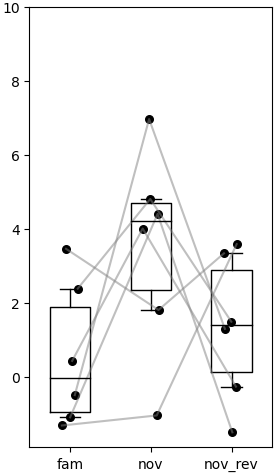

condition,fam (d0->d1),nov (d0->d1),nov_rev (d19->d17)
animal,,,
170,-1.3120,-1.0406,3.5846
51004,-1.0910,4.3998,-1.4960
51007,0.4320,4.0050,-0.2621
63,2.3832,4.8031,1.4899
64,3.4585,1.8068,3.3362
65,-0.4920,6.9614,1.2974


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,27.653162,2,13.826581,2.40377,0.140471,0.264333,0.691337
1,Error,57.520410,10,5.752041,NaN,NaN,NaN,NaN


condition,fam (d0->d1),nov (d0->d1),nov_rev (d19->d17)
animal,,,
170,-1.3120,-1.0406,3.5846
51004,-1.0910,4.3998,-1.4960
51007,0.4320,4.0050,-0.2621
63,2.3832,4.8031,1.4899
64,3.4585,1.8068,3.3362
65,-0.4920,6.9614,1.2974


,Timepoint 1,Timepoint 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Diff,SD Diff,Normal Dist.,Normality p-value
0,fam (d0->d1),nov (d0->d1),t-test,-2.1465,0.0846,0.2539,,-0.8763,Cohen's d,-2.9261,3.3392,True,0.9833
1,fam (d0->d1),nov_rev (d19->d17),wilcoxon,10.0000,1.0000,1.0000,,0.0428,r,-0.7619,2.2430,False,0.0433
2,nov (d0->d1),nov_rev (d19->d17),t-test,1.2382,0.2706,0.8118,,0.5055,Cohen's d,2.1642,4.2815,True,0.1826


In [22]:
day_cols_fwd = st.day_labels(maps)
day_cols_rev = st.day_labels(['0'] + maps[:-1])
first_day_conditions = ['fam (d0->d1)', 'nov (d0->d1)', 'nov_rev (d19->d17)']

# Forward novel subspace
novel = np.vstack([data[1] for data in forward_data_pop_geometry_subspace])
novel_rev = np.vstack([data[1] for data in reverse_data_pop_geometry_subspace])[:, ::-1]

print_large('\n' + '='*50)
print_large('Subspace angles')
print_large('='*50)
fig,ax=plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([novel,novel_rev], maps, directions=[True, False],colors=['b','k'], labels=['nov', 'nov_rev'], plot_individual=True, ylim=[-0.1, 1], ax=ax)
plt.show()  
print_large('\nTWO-WAY REPEATED ANOVA')
anova=st.repeated_measures_anova_general(
    [novel,novel_rev], row_labels=animal_ids,
    col_labels=[day_cols_fwd, day_cols_rev],
    condition_labels=['nov', 'nov_rev'],
    title='Subspace angles: novel forward (vs d0) vs novel reverse (vs d19)')
display(anova[0])
display(anova[1])

print_large('RM ANOVA: Novel to day 20 (reverse)')
display(st.repeated_measures_anova_single_condition(
    novel_rev, row_labels=animal_ids, col_labels=day_cols_rev,
    condition_label='nov_rev', title='Subspace angles: novel reverse (vs d19)'))
print_large('RM ANOVA: Novel to day 1 (forward)')
display(st.repeated_measures_anova_single_condition(
    novel, row_labels=animal_ids, col_labels=day_cols_fwd,
    condition_label='nov', title='Subspace angles: novel forward (vs d0)'))

fam = np.vstack([data[0] for data in forward_data_pop_geometry_subspace])
print_large('Comparing novel forward, novel reverse and fammilar day 1')
fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.vstack([[fam[:,0]],[novel[:,0]],[novel_rev[:,-1]]]).T, ['fam','nov', 'nov_rev'],ax, '',ylim=[-0.2,0.6])
plt.show()  
print_large('RM ANOVA: Novel forward, novel reverse and fammilar day 1')
display(st.repeated_measures_anova_single_condition(
    np.vstack([[fam[:,0]],[novel[:,0]],[novel_rev[:,-1]]]).T,
    row_labels=animal_ids, col_labels=first_day_conditions, col_name='condition',
    title='Subspace angles after one day: familiar vs novel forward vs novel reverse'))
print_large('Post hoc: Novel forward, novel reverse and fammilar day 1')
display(st.post_hoc_timepoints(
    [fam[:,0],novel[:,0],novel_rev[:,-1]],
    row_labels=animal_ids, col_labels=first_day_conditions, col_name='condition',
    title='Post hoc, subspace angles after one day'))


# Forward novel angles
novel = np.vstack([data[1] for data in forward_data_pop_geometry_angles])
novel_rev = np.vstack([data[1] for data in reverse_data_pop_geometry_angles])[:, ::-1]
print_large('\n' + '='*50)
print_large('Edge angles')
print_large('='*50)
fig,ax=plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([novel,novel_rev], maps, directions=[True, False],colors=['b','k'], labels=['nov', 'nov_rev'], plot_individual=True, ylim=[-0.1, 1], ax=ax)
plt.show()  
print_large('\nTWO-WAY REPEATED ANOVA')
anova=st.repeated_measures_anova_general(
    [novel,novel_rev], row_labels=animal_ids,
    col_labels=[day_cols_fwd, day_cols_rev],
    condition_labels=['nov', 'nov_rev'],
    title='Edge angles: novel forward (vs d0) vs novel reverse (vs d19)')
display(anova[0])
display(anova[1])

print_large('RM ANOVA: Novel to day 20 (reverse)')
display(st.repeated_measures_anova_single_condition(
    novel_rev, row_labels=animal_ids, col_labels=day_cols_rev,
    condition_label='nov_rev', title='Edge angles: novel reverse (vs d19)'))
print_large('RM ANOVA: Novel to day 1 (forward)')
display(st.repeated_measures_anova_single_condition(
    novel, row_labels=animal_ids, col_labels=day_cols_fwd,
    condition_label='nov', title='Edge angles: novel forward (vs d0)'))

fam = np.vstack([data[0] for data in forward_data_pop_geometry_angles])
print_large('Comparing novel forward, novel reverse and fammilar day 1')
fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.vstack([[fam[:,0]],[novel[:,0]],[novel_rev[:,-1]]]).T, ['fam','nov', 'nov_rev'],ax, '',ylim=[-0.2,0.6])
plt.show()  
print_large('RM ANOVA: Novel forward, novel reverse and fammilar day 1')
display(st.repeated_measures_anova_single_condition(
    np.vstack([[fam[:,0]],[novel[:,0]],[novel_rev[:,-1]]]).T,
    row_labels=animal_ids, col_labels=first_day_conditions, col_name='condition',
    title='Edge angles after one day: familiar vs novel forward vs novel reverse'))
print_large('Post hoc: Novel forward, novel reverse and fammilar day 1')
display(st.post_hoc_timepoints(
    [fam[:,0],novel[:,0],novel_rev[:,-1]],
    row_labels=animal_ids, col_labels=first_day_conditions, col_name='condition',
    title='Post hoc, edge angles after one day'))


# Forward novel topology
novel = np.vstack([data[1] for data in forward_data_topology])
novel_rev = np.vstack([data[1] for data in reverse_data_topology])[:, ::-1]
print_large('\n' + '='*50)
print_large('Persistent homology')
print_large('='*50)
fig,ax=plt.subplots(figsize=(4, 5))
plots.plot_average_geometry([novel,novel_rev], maps, directions=[True, False],colors=['b','k'], labels=['nov', 'nov_rev'], plot_individual=True, ylim=[-4.5, 21], ax=ax)
fig.tight_layout()
plt.show() 
print_large('\nTWO-WAY REPEATED ANOVA')
anova=st.repeated_measures_anova_general(
    [novel,novel_rev], row_labels=animal_ids,
    col_labels=[day_cols_fwd, day_cols_rev],
    condition_labels=['nov', 'nov_rev'],
    title='Persistent homology: novel forward (vs d0) vs novel reverse (vs d19)')
display(anova[0])
display(anova[1])

print_large('RM ANOVA: Novel to day 20 (reverse)')
display(st.repeated_measures_anova_single_condition(
    novel_rev, row_labels=animal_ids, col_labels=day_cols_rev,
    condition_label='nov_rev', title='Persistent homology: novel reverse (vs d19)'))
print_large('RM ANOVA: Novel to day 1 (forward)')
display(st.repeated_measures_anova_single_condition(
    novel, row_labels=animal_ids, col_labels=day_cols_fwd,
    condition_label='nov', title='Persistent homology: novel forward (vs d0)'))

fam = np.vstack([data[0] for data in forward_data_topology])
print_large('Comparing novel forward, novel reverse and fammilar day 1')
fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.vstack([[fam[:,0]],[novel[:,0]],[novel_rev[:,-1]]]).T, ['fam','nov', 'nov_rev'],ax, '',ylim=[-1.9,10])
fig.tight_layout()
plt.show()  
print_large('RM ANOVA: Novel forward, novel reverse and fammilar day 1')
display(st.repeated_measures_anova_single_condition(
    np.vstack([[fam[:,0]],[novel[:,0]],[novel_rev[:,-1]]]).T,
    row_labels=animal_ids, col_labels=first_day_conditions, col_name='condition',
    title='Persistent homology after one day: familiar vs novel forward vs novel reverse'))
print_large('Post hoc: Novel forward, novel reverse and fammilar day 1')
display(st.post_hoc_timepoints(
    [fam[:,0],novel[:,0],novel_rev[:,-1]],
    row_labels=animal_ids, col_labels=first_day_conditions, col_name='condition',
    title='Post hoc, persistent homology after one day'))




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


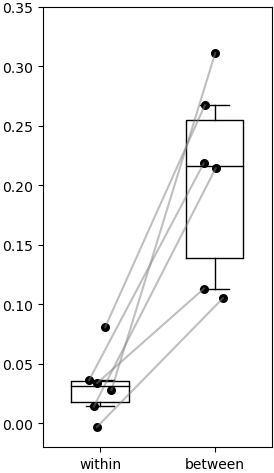

comparison,"d17 vs d19, Context1"
animal,
170,0.0340
51004,-0.0031
51007,0.0142
63,0.0365
64,0.0811
65,0.0281


comparison,d19 Context1 vs Context2
animal,
170,0.1133
51004,0.1051
51007,0.2143
63,0.2183
64,0.2671
65,0.3110


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,"d17 vs d19, Context1 | d19 Context1 vs Context2",within,between,t-test,-5.8726,0.0020,0.0020,**,-2.3975,Cohen's d,0.0318,0.2048,-0.173,0.0722,6,True,0.7203


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


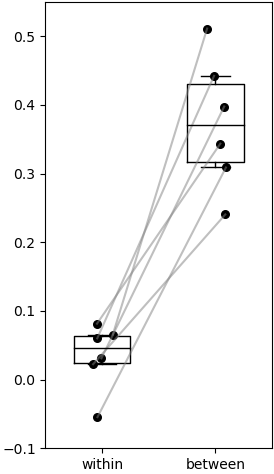

comparison,"d17 vs d19, Context1"
animal,
170,0.0225
51004,-0.0546
51007,0.0815
63,0.0654
64,0.0310
65,0.0601


comparison,d19 Context1 vs Context2
animal,
170,0.2406
51004,0.3090
51007,0.3437
63,0.5114
64,0.3978
65,0.4423


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,"d17 vs d19, Context1 | d19 Context1 vs Context2",within,between,t-test,-9.9204,0.0002,0.0002,***,-4.05,Cohen's d,0.0343,0.3741,-0.3398,0.0839,6,True,0.5461


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


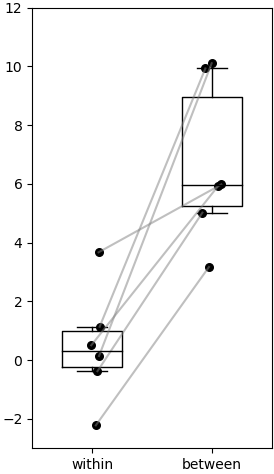

comparison,"d17 vs d19, Context1"
animal,
170,0.1414
51004,-0.3752
51007,-2.2194
63,3.6691
64,1.1371
65,0.5046


comparison,d19 Context1 vs Context2
animal,
170,10.1029
51004,5.0186
51007,3.1697
63,5.9773
64,9.9244
65,5.9201


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,"d17 vs d19, Context1 | d19 Context1 vs Context2",within,between,t-test,-5.5235,0.0027,0.0027,**,-2.255,Cohen's d,0.4763,6.6855,-6.2092,2.7536,6,True,0.4427


In [30]:

between_subspace = [data[3] for data in forward_data_pop_geometry_subspace]
within_subspace = [data[4] for data in forward_data_pop_geometry_subspace]

between_angles = [data[3] for data in forward_data_pop_geometry_angles]
within_angles = [data[4] for data in forward_data_pop_geometry_angles]

between_topology = [data[3] for data in forward_data_topology]
within_topology = [data[4] for data in forward_data_topology]

within_between_days = [['d17 vs d19, Context1'], ['d19 Context1 vs Context2']]

print_large('Subspace angles')
fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.hstack((within_subspace,between_subspace)), ['within','between'],ax, '', ylim=[-0.02, 0.35])
fig.tight_layout()
plt.show()
display(st.post_hoc_repeated_measures(
    [np.vstack(within_subspace),np.vstack(between_subspace)],
    row_labels=animal_ids, col_labels=within_between_days,
    condition_labels=['within', 'between'], col_name='comparison',
    title='Subspace angles: within context (d17 vs d19) vs between contexts (d19)'))


print_large('Edge angles')
fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.hstack((within_angles,between_angles)), ['within','between'],ax, '', ylim=[-0.1, 0.55])
fig.tight_layout()
plt.show()
display(st.post_hoc_repeated_measures(
    [np.vstack(within_angles),np.vstack(between_angles)],
    row_labels=animal_ids, col_labels=within_between_days,
    condition_labels=['within', 'between'], col_name='comparison',
    title='Edge angles: within context (d17 vs d19) vs between contexts (d19)'))

print_large('Persistent homology')
fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.hstack((within_topology,between_topology)), ['within','between'],ax, '', ylim=[-3, 12])
fig.tight_layout()
plt.show()
display(st.post_hoc_repeated_measures(
    [np.vstack(within_topology),np.vstack(between_topology)],
    row_labels=animal_ids, col_labels=within_between_days,
    condition_labels=['within', 'between'], col_name='comparison',
    title='Persistent homology: within context (d17 vs d19) vs between contexts (d19)'))